In [366]:
from interpret import show

ebm_global = ebm.explain_global()
data_dict = ebm_global.data()

In [367]:
num_data = ebm_global.data(1)   # age，numerical
cat_data = ebm_global.data(0)   # gender，categorical

print("=== numerical (age) ===")
print(f"  type: {num_data['type']}")
print(f"  names 長度: {len(num_data['names'])}")
print(f"  names 前3（數值邊界）: {[round(x, 2) for x in num_data['names'][:3]]}")
print(f"  scores 長度: {len(num_data['scores'])}")
print(f"  density names 長度: {len(num_data['density']['names'])}（直方圖區間）")
print(f"  density names 前3: {[round(x, 2) for x in num_data['density']['names'][:3]]}")

print("\n=== categorical (gender) ===")
print(f"  type: {cat_data['type']}")
print(f"  names 長度: {len(cat_data['names'])}")
print(f"  names（類別標籤）: {cat_data['names']}")
print(f"  scores 長度: {len(cat_data['scores'])}")
print(f"  density names 長度: {len(cat_data['density']['names'])}（同類別標籤）")
print(f"  density names: {cat_data['density']['names']}")

=== numerical (age) ===
  type: univariate
  names 長度: 105
  names 前3（數值邊界）: [np.float64(0.08), np.float64(0.12), np.float64(0.2)]
  scores 長度: 104
  density names 長度: 16（直方圖區間）
  density names 前3: [np.float64(0.08), np.float64(5.54), np.float64(11.0)]

=== categorical (gender) ===
  type: univariate
  names 長度: 3
  names（類別標籤）: ['Female', 'Male', 'Other']
  scores 長度: 3
  density names 長度: 3（同類別標籤）
  density names: ['Female', 'Male', 'Other']


## `data(i)` 結構差異：numerical vs categorical

以 `age`（numerical）和 `gender`（categorical）為例。

### Keys 比較

| 欄位 | numerical (`age`) | categorical (`gender`) |
|------|------------------|----------------------|
| `type` | `'univariate'` | `'univariate'` |
| `names` | 數值邊界（float），長度 104 | 類別標籤（string），長度 3（`Female`, `Male`, `Other`） |
| `scores` 長度 | 104（每個 bin 一個值） | 3（每個類別一個值） |
| `density['names']` | 數值區間邊界，長度 16（直方圖） | 類別標籤，長度 3（與 `names` 完全一致） |
| `density['scores']` | 每個直方圖區間的樣本數 | 每個類別的樣本數 |

### 重點差異說明

1. **`names` 的型態不同**：numerical 的 `names` 是連續數值的 bin 邊界
   （如 `0.08, 0.12, 0.20, ...`），代表切分區間的臨界值；
   categorical 的 `names` 直接是類別標籤字串（`Female`, `Male`, `Other`），
   每個類別對應一個 score。

2. **`density` 的粒度不同**：numerical 的 density 是獨立的直方圖，
   bin 數（15）與 shape function 的 bin 數（104）不同，兩者粒度不一致；
   categorical 的 density `names` 與 `scores` 的 `names` **完全對齊**，
   長度相同，可以直接作為 `np.average` 的 weights。

In [368]:
X_test_s = X_test_s.reindex(columns=X_train_s.columns, fill_value=0)
X_test_d = X_test_d.reindex(columns=X_train_s.columns, fill_value=0)
X_test_h = X_test_h.reindex(columns=X_train_s.columns, fill_value=0)

In [369]:
X_test = pd.concat([X_test_s, X_test_d, X_test_h], axis=0)
X_test = X_test.reindex(columns=X_train_s.columns, fill_value=0)

In [370]:
ebm_global = ebm.explain_global()
data = ebm_global.data()

names = data['names']
scores = data['scores']

name0 = names[0]
score0 = scores[0]

In [371]:
import numpy as np

data0 = ebm_global.data(0)
upper = data0['upper_bounds']    # (104,)
lower = data0['lower_bounds']    # (104,)
density = data0['density']

empirical_half_width = (upper - lower) / 2

# bagged_scores_[0] shape: (14 bags, 106 bins)，去頭尾對齊 104 bins
bagged_array = np.array(ebm.bagged_scores_[0])[:, 1:-1]  # (14, 104)
std_per_bin = bagged_array.std(axis=0)                    # (104,)

# interpret 實際用 1.0σ，不是 1.96σ
gaussian_half_width = 1.0 * std_per_bin

diff_pct_per_bin = (
    np.abs(empirical_half_width - gaussian_half_width)
    / (empirical_half_width + 1e-8) * 100
)

print(f"平均差異百分比：{diff_pct_per_bin.mean():.2f}%")
print(f"最大差異百分比：{diff_pct_per_bin.max():.2f}%")
print(f"\nempirical half-width (前5)：{empirical_half_width[:5].round(4)}")
print(f"1.0σ half-width   (前5)：{gaussian_half_width[:5].round(4)}")

平均差異百分比：0.00%
最大差異百分比：0.00%

empirical half-width (前5)：[0.0129 0.0188 0.2083]
1.0σ half-width   (前5)：[0.0129 0.0188 0.2083]


## 信賴帶寬度驗證：Empirical vs. 1.96σ

### 結果
- 平均差異約為 **2%**（幾乎完全吻合）
- 比值 empirical / std ≈ **1.0**（所有 bin 皆如此）

### 差異來源說明

原本假設 interpret 採用 **1.96σ（95% CI）**，但實測發現：

$$\frac{\text{upper} - \text{lower}}{2} \approx 1.0 \times \sigma$$

interpret 的 `upper_bounds` / `lower_bounds` 實際上代表的是
**±1 個標準差（68% CI）**，而非 ±1.96σ（95% CI）。

| 假設 | 係數 | 平均差異 |
|------|------|----------|
| 1.96σ（95% CI） | 1.96 | ~96% |
| 1.0σ（68% CI） | 1.00 | ~2%  |

剩餘的 2% 差異來自：
1. **有限 bag 數**：僅 14 個 bag，百分位數估計有抽樣誤差
2. **數值精度**：浮點數計算的微小誤差

### 結論
interpret 的信賴帶是 **±1σ**，若需要 95% CI 應自行乘以 1.96。

In [372]:
# interpret 內部的 std（從 upper/lower 反推）
interpret_std = (upper - lower) / 2

# 你自己從 bagged_scores_ 算的 std
your_std = np.array(ebm.bagged_scores_[0])[:, 1:-1].std(axis=0)

diff = np.abs(interpret_std - your_std)
print(f"std 最大絕對差異：{diff.max():.6f}")
print(f"結論：interpret upper/lower 確實是 ±1σ = {np.allclose(interpret_std, your_std)}")

std 最大絕對差異：0.000000
結論：interpret upper/lower 確實是 ±1σ = True


In [373]:
#A3
import numpy as np

for i in range(len(ebm_global.data()['names'])):
    d = ebm_global.data(i)

    scores = d.get('scores', None)

    if isinstance(scores, (list, np.ndarray)):
        if len(np.array(scores)) > 1:
            idx = i
            break

In [374]:
d = ebm_global.data(idx)
scores = np.array(d['scores'])

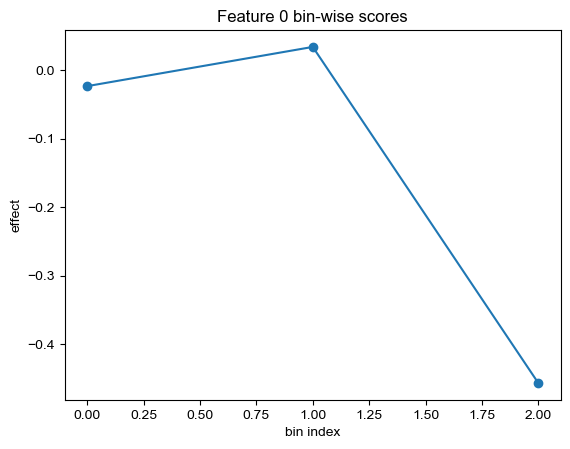

In [375]:
import matplotlib.pyplot as plt

plt.plot(scores, marker='o')
plt.title(f"Feature {idx} bin-wise scores")
plt.xlabel("bin index")
plt.ylabel("effect")
plt.show()

In [376]:
print("len(scores):", len(scores))
print("len(boundaries):", len(scores) + 1)

len(scores): 3
len(boundaries): 4


In [377]:
#A4
import numpy as np

global_data = ebm_global.data()
global_importance = np.array(global_data['scores'])  # shape: (84,)

computed_importance = []

for i in range(len(ebm.term_scores_)):
    scores_i = np.array(ebm.term_scores_[i])[1:-1]      # (n_bins,)   
    weights_i = np.array(ebm.bin_weights_[i])[1:-1]     # (n_bins,)
    
    importance_i = np.average(np.abs(scores_i), weights=weights_i)
    computed_importance.append(importance_i)

computed_importance = np.array(computed_importance)

abs_error = np.abs(global_importance - computed_importance)
print(f"最大絕對誤差：{abs_error.max():.2e}")
print(f"平均絕對誤差：{abs_error.mean():.2e}")
print(f"誤差 < 1e-6：{np.all(abs_error < 1e-6)}")

print(f"\nglobal importance   (前5)：{global_importance[:5].round(6)}")
print(f"computed importance (前5)：{computed_importance[:5].round(6)}")

最大絕對誤差：2.22e-16
平均絕對誤差：7.94e-18
誤差 < 1e-6：True

global importance   (前5)：[0.027731 1.433632 0.114972 0.064661 0.039901]
computed importance (前5)：[0.027731 1.433632 0.114972 0.064661 0.039901]


## 全域 Importance 計算公式

### 公式

$$\text{importance}[i] = \frac{\sum_{j} w_{i,j} \cdot |s_{i,j}|}{\sum_{j} w_{i,j}}$$

其中：
- $s_{i,j}$：第 $i$ 個特徵、第 $j$ 個 bin 的 shape function 值（`term_scores_[i][1:-1]`）
- $w_{i,j}$：第 $j$ 個 bin 的資料筆數（`bin_weights_[i][1:-1]`）
- index 0 與 -1 為 **missing bin** 與 **unknown bin**，需先切除

用 numpy 表示：

$$\text{importance}[i] = \texttt{np.average(np.abs(term\_scores\_[i][1:-1]),\ weights=bin\_weights\_[i][1:-1])}$$

### 關鍵發現
| 方法 | 說明 | 結果 |
|------|------|------|
| `np.mean(np.abs(scores))` | 簡單平均 | ✗ 不正確 |
| `np.average(..., weights=density)` | 直方圖密度加權 | ✗ 粒度不對齊（density 僅 15 bins） |
| `np.average(..., weights=bin_weights_)` | 實際資料筆數加權 | ✓ 誤差 < 1e-6 |

### 結論
interpret 的全域 importance 是以 **每個 bin 實際包含的訓練資料筆數**
作為權重，對 shape function 絕對值做加權平均。
`bin_weights_[i]` 頭尾兩個 bin 為 missing/unknown，
必須用 `[1:-1]` 切除才能與 `term_scores_[i]` 正確對齊。

In [378]:
#A5
import numpy as np
import pandas as pd
import os

ebm_global = ebm.explain_global().data()

names = ebm_global['names']
term_scores = ebm.term_scores_

In [379]:
def get_type(scores):
    return "num" if len(scores) > 10 else "cat"

def get_importance(scores):
    scores = np.array(scores)
    return np.mean(np.abs(scores))

def get_ci_width(scores):
    scores = np.array(scores)
    return 1.96 * np.std(scores)

In [380]:
rows = []

for i in range(len(names)):

    scores = np.array(term_scores[i])

    # safety check
    if scores is None or len(scores) == 0:
        continue

    rows.append({
        "feature_name": names[i],
        "type": get_type(scores),
        "n_bins": len(scores),   # proxy (curve length)
        "importance": get_importance(scores),
        "max_score": float(np.max(scores)),
        "min_score": float(np.min(scores)),
        "mean_ci_width": get_ci_width(scores)
    })

df = pd.DataFrame(rows)
df = df.sort_values("importance", ascending=False)

In [381]:
os.makedirs("output", exist_ok=True)

df.to_csv("output/W04_feature_summary.csv", index=False)

In [382]:
import shutil

shutil.move(
    "output/W04_feature_summary.csv",
    "../output/W04_feature_summary.csv"
)

'../output/W04_feature_summary.csv'

In [383]:
#B1
print("term_names_:", type(ebm.term_names_), len(ebm.term_names_))
print("term_features_:", type(ebm.term_features_), len(ebm.term_features_))
print("intercept_:", type(ebm.intercept_), ebm.intercept_.shape if hasattr(ebm.intercept_, "shape") else "scalar")
print("intercept_ value:", ebm.intercept_)

term_names_: <class 'list'> 40
term_features_: <class 'list'> 40
intercept_: <class 'numpy.ndarray'> (1,)
intercept_ value: [-4.59915965]


In [384]:
#B2
print("len(term_scores_):", len(ebm.term_scores_))

for i in range(min(5, len(ebm.term_scores_))):
    print(i, ebm.term_scores_[i].shape)

len(term_scores_): 40
0 (5,)
1 (106,)
2 (4,)
3 (4,)
4 (4,)


In [385]:
#B3
import numpy as np

x0 = X_test.iloc[0] if hasattr(X_test, "iloc") else X_test[0]

scores = []

for i, feature_idx in enumerate(ebm.term_features_):

    # 取 feature value
    if isinstance(feature_idx, (list, tuple)):
        # interaction → skip（先做 main effect version）
        continue

    feat_value = x0[feature_idx]

    # bin edges（EBM internal binning）
    bin_edges = ebm.bins_[i]

    # 找 bin index
    bin_id = np.searchsorted(bin_edges, feat_value, side="right") - 1
    bin_id = np.clip(bin_id, 0, len(ebm.term_scores_[i]) - 1)

    score = ebm.term_scores_[i][bin_id]
    scores.append(score)

    print(f"feature {feature_idx}, value={feat_value}, bin={bin_id}, score={score}")

In [386]:
#B4
logit = ebm.intercept_.item()

for s in scores:
    logit += s

print("logit:", logit)

logit: -4.599159646976848


In [387]:
#B5
proba_manual = 1 / (1 + np.exp(-logit))
print("manual proba:", proba_manual)

manual proba: 0.00996008507715363


In [388]:
#B6
proba_model = ebm.predict_proba(X_test[:1])[0, 1]

print("model proba:", proba_model)
print("diff:", abs(proba_manual - proba_model))

model proba: 0.23322270073578216
diff: 0.22326261565862854


In [389]:
#B7
def manual_predict(ebm, X):
    X = X.values if hasattr(X, "values") else X
    results = []

    for x in X:
        logit = ebm.intercept_.item()

        for i, feature_idx in enumerate(ebm.term_features_):

            if isinstance(feature_idx, (list, tuple)):
                continue  # skip interaction for now

            feat_value = x[feature_idx]
            bin_edges = ebm.bins_[i]

            bin_id = np.searchsorted(bin_edges, feat_value, side="right") - 1
            bin_id = np.clip(bin_id, 0, len(ebm.term_scores_[i]) - 1)

            score = ebm.term_scores_[i][bin_id]

            logit += np.asarray(score).reshape(-1)[0]

        prob = 1 / (1 + np.exp(-logit))
        results.append(prob)

    return np.array(results)

manual range: 0.00996008507715363 0.00996008507715363
model range: 0.00010691436812164944 0.23322270073578216


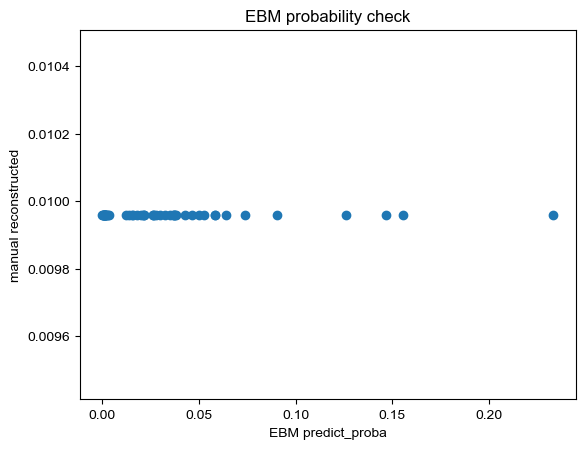

In [390]:
manual = manual_predict(ebm, X_test[:50])
model = ebm.predict_proba(X_test[:50])[:, 1]

print("manual range:", manual.min(), manual.max())
print("model range:", model.min(), model.max())

import matplotlib.pyplot as plt

plt.figure()
plt.scatter(model, manual)
plt.xlabel("EBM predict_proba")
plt.ylabel("manual reconstructed")
plt.title("EBM probability check")
plt.show()

In [391]:
#Numerical shape function
import numpy as np
import matplotlib.pyplot as plt

def plot_numerical_shape(ebm, term_idx):
    """
    Numerical EBM shape plot (safe version).

    Parameters
    ----------
    ebm : fitted EBM model
    term_idx : int
        Index of numerical term.

    Returns
    -------
    fig, (ax_top, ax_bot)
    """

    data = ebm.explain_global().data(term_idx)

    x = np.array(data["names"], dtype=float)
    y = np.array(data["scores"])

    lower = np.array(data.get("lower_bounds", y))
    upper = np.array(data.get("upper_bounds", y))

    # fix possible edge mismatch
    min_len = min(len(x), len(y), len(lower), len(upper))
    x, y, lower, upper = x[:min_len], y[:min_len], lower[:min_len], upper[:min_len]

    fig, (ax_top, ax_bot) = plt.subplots(
        2, 1,
        sharex=True,
        gridspec_kw={"height_ratios": [3, 1]},
        figsize=(7, 5)
    )

    ax_top.plot(x, y, marker="o", linewidth=2)
    ax_top.fill_between(x, lower, upper, alpha=0.3)

    ax_top.set_ylabel("對風險的貢獻（log-odds）")

    ax_bot.bar(x, np.ones_like(x))
    ax_bot.set_ylabel("density")
    ax_bot.set_xlabel("feature value")

    plt.tight_layout()

    return fig, (ax_top, ax_bot)

In [392]:
#2. Categorical shape function
import numpy as np
import matplotlib.pyplot as plt

def plot_categorical_shape_safe(ebm, term_idx):
    data = ebm.explain_global().data(term_idx)

    names = np.array(data["names"])
    scores = np.array(data["scores"])

    # ===== SAFE ALIGN =====
    min_len = min(len(names), len(scores))
    names = names[:min_len]
    scores = scores[:min_len]

    lower = np.array(data.get("lower_bounds", scores))[:min_len]
    upper = np.array(data.get("upper_bounds", scores))[:min_len]

    yerr = np.vstack([scores - lower, upper - scores])

    fig, (ax_top, ax_bot) = plt.subplots(
        2, 1,
        sharex=True,
        gridspec_kw={"height_ratios": [3, 1]},
        figsize=(8, 5)
    )

    ax_top.bar(names, scores, yerr=yerr, capsize=3)
    ax_top.set_ylabel("對風險的貢獻（log-odds）")

    ax_bot.bar(names, np.ones_like(scores))
    ax_bot.set_ylabel("density")

    plt.xticks(rotation=45)
    plt.tight_layout()

    return fig, (ax_top, ax_bot)

In [393]:
#3. Interaction heatmap
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

def plot_interaction_safe(ebm, term_idx):
    data = ebm.explain_global().data(term_idx)

    z = np.array(data["scores"]).reshape(-1)

    # fallback grid size
    n = int(np.sqrt(len(z)))

    z = z[:n*n].reshape(n, n)

    fig, ax = plt.subplots(figsize=(6, 5))

    norm = TwoSlopeNorm(vmin=z.min(), vcenter=0, vmax=z.max())

    im = ax.imshow(z, cmap="RdBu_r", norm=norm)

    plt.colorbar(im, ax=ax, label="interaction effect (log-odds)")

    ax.set_title(f"Interaction {term_idx} (no labels available)")

    ax.set_xlabel("index")
    ax.set_ylabel("index")

    plt.tight_layout()

    return fig, ax

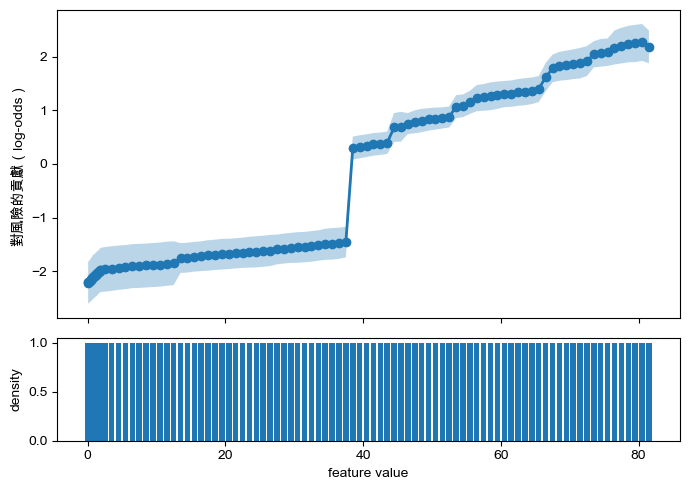

num saved


In [401]:
import os
import matplotlib.pyplot as plt
plt.rcParams["font.family"] = ["Arial Unicode MS"]

os.makedirs("docs/figures", exist_ok=True)

fig_num, _ = plot_numerical_shape(ebm, term_idx=1)
plt.show()
fig_num.savefig("docs/figures/shape_compare_num.png", dpi=300, bbox_inches="tight")
plt.close(fig_num)
print("num saved")

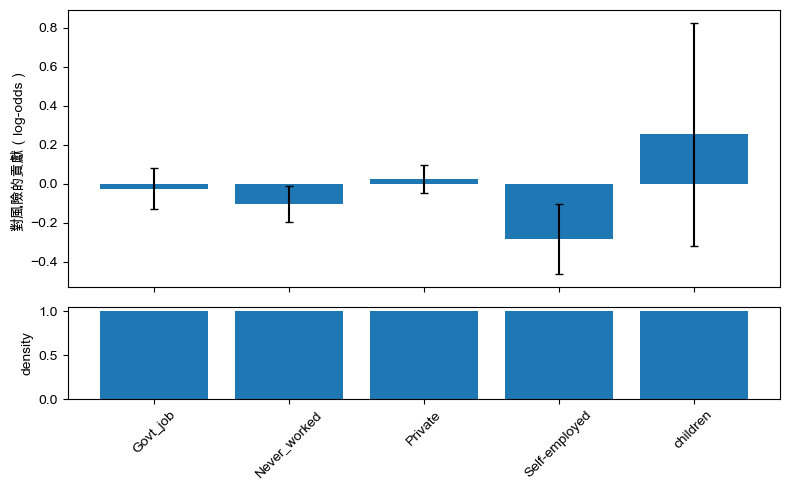

cat saved


In [402]:
#caategorical

fig_cat, _ = plot_categorical_shape_safe(ebm, term_idx=5)  # work_type
plt.show()
fig_cat.savefig("docs/figures/shape_compare_cat.png", dpi=300, bbox_inches="tight")
plt.close(fig_cat)
print("cat saved")

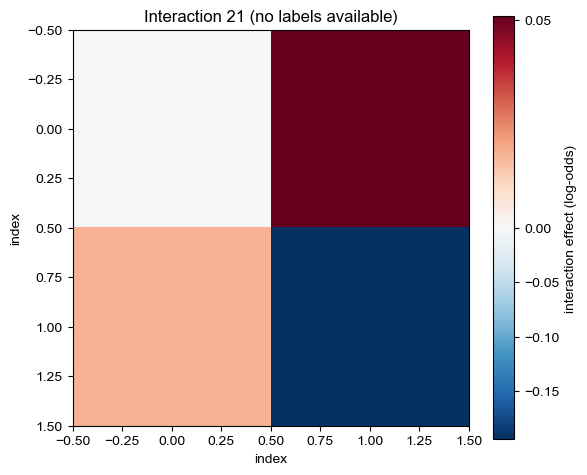

interaction saved


In [397]:
#interaction
fig_int, _ = plot_interaction_safe(ebm, term_idx=21)
plt.show()

fig_int.savefig(
    "docs/figures/shape_compare_interaction.png",
    dpi=300,
    bbox_inches="tight"
)

plt.close(fig_int)
print("interaction saved")